In [181]:
library(dplyr)
library(tidyr)
library(igraph)
library(ggraph)
library(ggfortify)

In [182]:
counts = read.csv("/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Final_cell_label_counts.csv",row.names = 1)

In [183]:
edges <- bind_rows(
  counts %>% distinct(Classification_L1) %>%
    transmute(from = "root", to = Classification_L1),

  counts %>% distinct(Classification_L1, Classification_L2) %>%
    transmute(from = Classification_L1, to = Classification_L2),

  counts %>% distinct(Classification_L2, Classification_L3) %>%
    transmute(from = Classification_L2, to = Classification_L3),

  counts %>% distinct(Classification_L3, Classification_L4) %>%
    transmute(from = Classification_L3, to = Classification_L4)
)

In [184]:
edges = edges[which(edges$from!=edges$to),]

In [185]:
edges

,from,to
,<chr>,<chr>
1,root,B cells
2,root,HSPC
3,root,ILCs
4,root,Myeloid cells
5,root,Platelets
6,root,T cells
10,Myeloid cells,DC
11,Myeloid cells,Granulocytes
12,Myeloid cells,Monocytes


In [186]:
nodes <- bind_rows(
  counts %>% 
    group_by(Classification_L4) %>%
    summarise(name = first(Classification_L4), value = sum(Cell_counts), depth=3) %>% select(-Classification_L4),

  counts %>% 
    group_by(Classification_L3) %>%
    summarise(name = first(Classification_L3), value = sum(Cell_counts),depth=2) %>% select(-Classification_L3),

  counts %>% 
    group_by(Classification_L2) %>%
    summarise(name = first(Classification_L2), value = sum(Cell_counts),depth=1) %>% select(-Classification_L2),

  counts %>% 
    group_by(Classification_L1) %>%
    summarise(name = first(Classification_L1), value = sum(Cell_counts),depth=0) %>% select(-Classification_L1),

  tibble(name = "root", value = sum(counts$Cell_counts))
) %>%
  distinct(name, .keep_all = TRUE)

In [187]:
nodes

name,value,depth
<chr>,<int>,<dbl>
ALPL- MARCKS- NDNs,2248504,3
ASDC,5155,3
Adaptive NK cells,2350631,3
Atypical naïve B cells,11681,3
Basophils,34153,3
CCR4+ CD8+ Tcm,102986,3
CCR4- CD8+ Tcm,31986,3
CD14+ cDC2,85330,3
CD177int iLDNs,9629,3


In [188]:
g <- graph_from_data_frame(edges, vertices = nodes)

In [193]:
E(g)

+ 130/130 edges from e8959d4 (vertex names):
 [1] root         ->B cells                  
 [2] root         ->HSPC                     
 [3] root         ->ILCs                     
 [4] root         ->Myeloid cells            
 [5] root         ->Platelets                
 [6] root         ->T cells                  
 [7] Myeloid cells->DC                       
 [8] Myeloid cells->Granulocytes             
 [9] Myeloid cells->Monocytes                
[10] T cells      ->CD4+ T cells             
+ ... omitted several edges

Warning message in geom_node_text(aes(label = name, angle = node_angle(x, y)), hjust = "outward", :
“Ignoring unknown parameters: `fill`”


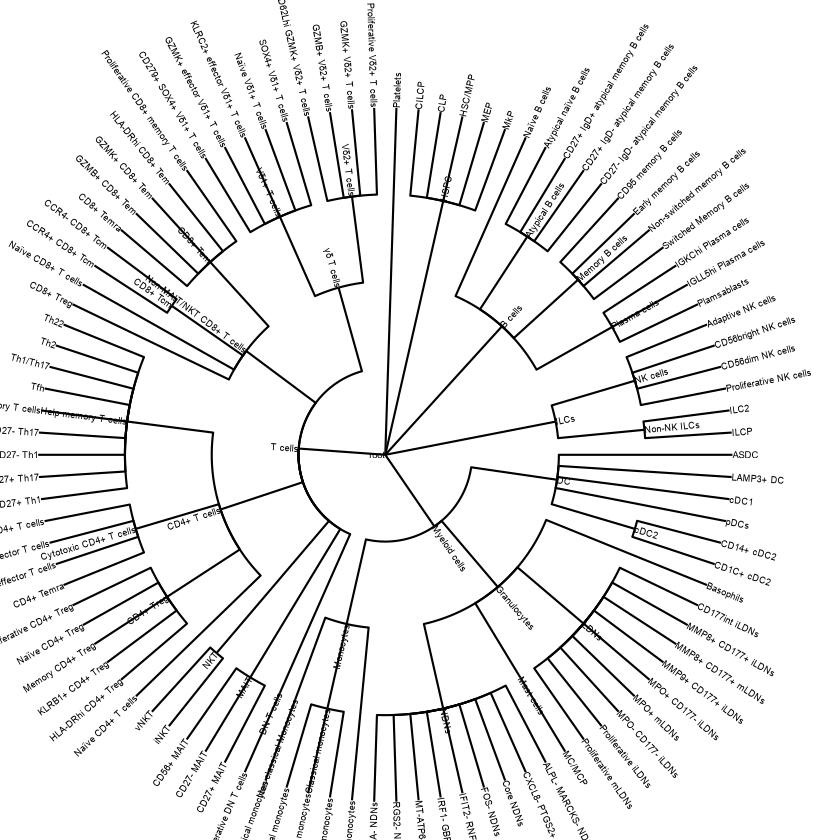

In [203]:
library(ggraph)
library(ggplot2)

p = ggraph(g, layout = "dendrogram", circular = TRUE) +

  ## 1️⃣ 主体：正交分叉（核心）
  geom_edge_elbow(
    #aes(colour = value),
    alpha = 1,
    width = 0.6,
    show.legend = FALSE
  ) +

  ##末端文字：始终朝外
  geom_node_text(aes(label = name, angle = node_angle(x, y)),
    hjust = 'outward', size = 2,fill = "white",
      ) +

  coord_fixed() +
  theme_void()+expand_limits(x = 1.2, y = 1.2)
p

In [204]:
ggsave('p.pdf',p,width = 10,height = 10)

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'γδ T cells' in 'mbcsToSbcs': for γ (U+03B3)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'γδ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD279+ SOX4+ Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_t

# 其他可选

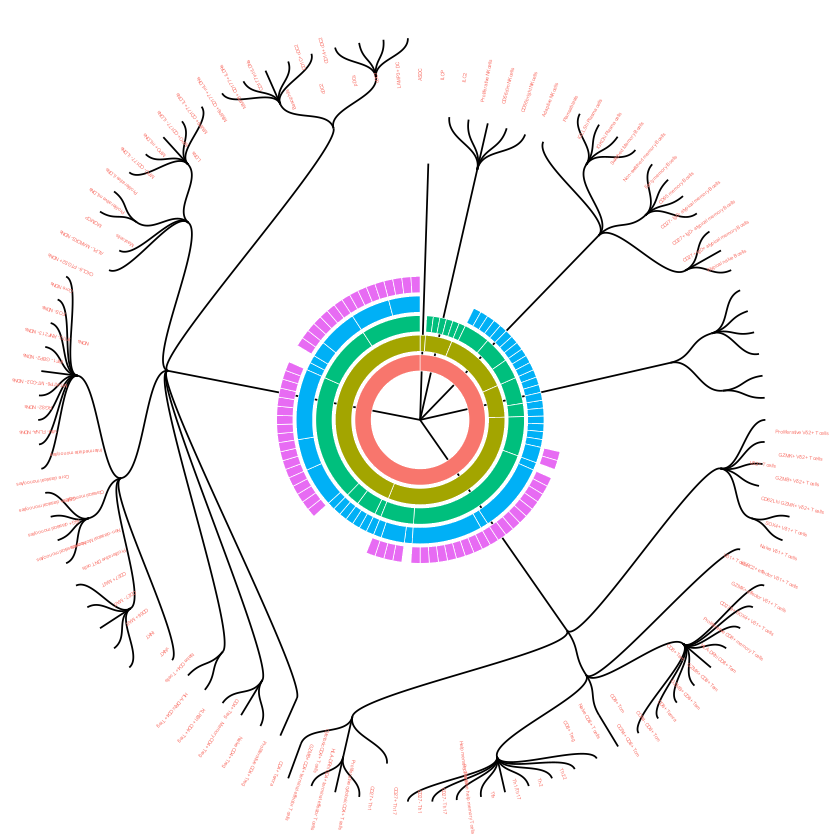

In [79]:
ggraph(g, layout = "partition", circular = TRUE) +
 geom_edge_diagonal() +
  geom_node_arc_bar(
    aes(
      start = start,
      end   = end,
      r0    = 0.30 + depth * 0.12,
      r     = 0.30 + depth * 0.12 + 0.10,
      fill  = factor(depth)
    ),
    colour = "white",
    size = 0.2
  ) +

  geom_node_text(
  data = function(x) subset(x, depth > 2),
  aes(
    x     = (r0 + r) / 2 * cos((start + end) / 2),
    y     = (r0 + r) / 2 * sin((start + end) / 2),
    label = name,
    angle = (start + end) / 2 * 180 / pi,
      hjust = "middle",
      vjust = "middle",
      color = "black",
  ),
  size = 1
) +
  coord_fixed() +
  theme_void() +
  theme(legend.position = "none")

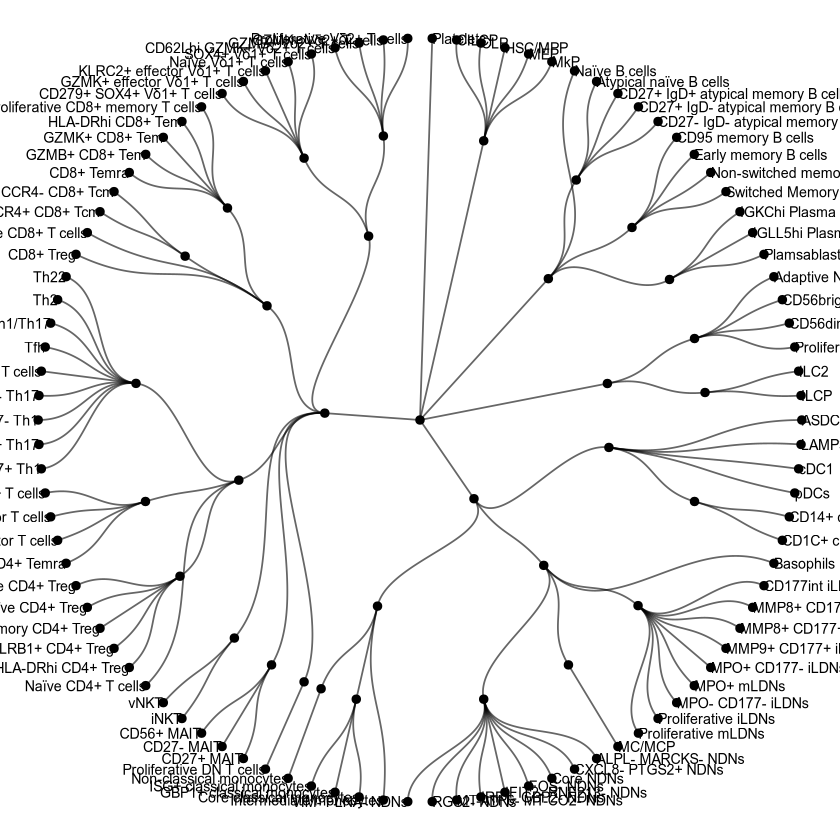

In [77]:
ggraph(g, layout = "dendrogram", circular = TRUE) +
  geom_edge_diagonal(alpha = 0.6) +
  geom_node_point(size = 2) +
  geom_node_text(
    aes(label = name, filter = leaf),
    #angle = -node_angle(x, y),
    hjust = "outward",
    size = 3
  ) +
  coord_fixed() +
  theme_void()


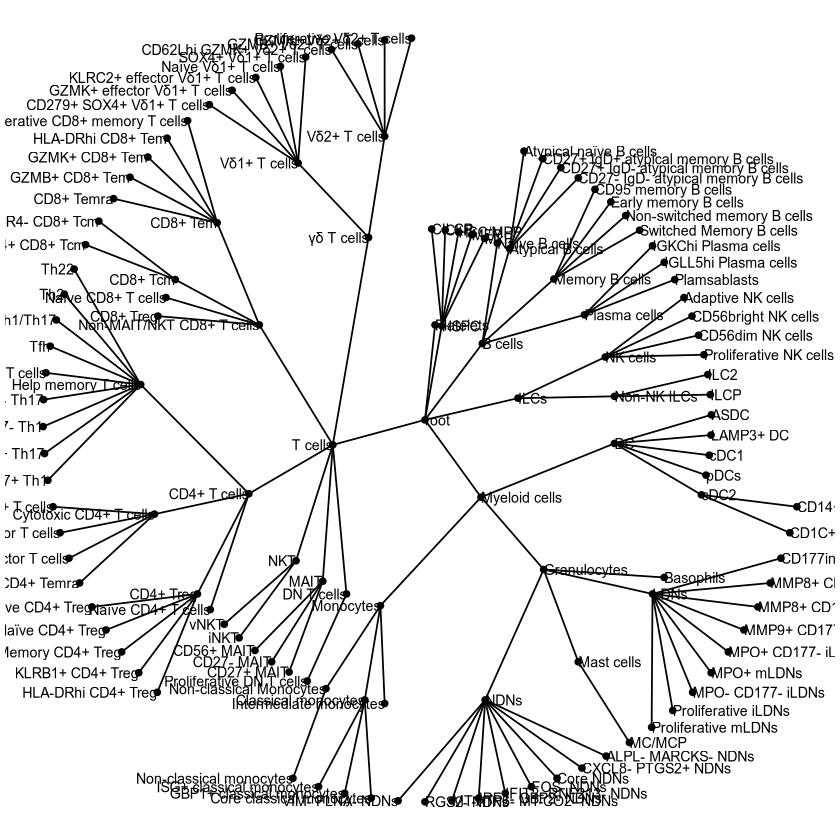

In [81]:
ggraph(g, layout = "tree", circular = TRUE) +
  geom_edge_link() +
  geom_node_point(size = 1.5) +
  geom_node_text(
    aes(label = name),
    size = 3,
    #angle = node_angle(x, y),
    hjust = "outward"
  ) +
  coord_fixed() +
  theme_void()
